# Project 2 — Housing Price Prediction

## Problem Definition
In this project, we want to predict house sale prices using linear regression. Our success metric is RMSPE (Root Mean Square Percentage Error). Our goal is to create this model with a minimal, effective feature set.

## Data Collection
- The data source for the project is from [Amazon AWS] (https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv).

- The data dictionary provided by Amazon can be found here (https://www.google.com/url?q=https%3A%2F%2Fddc-datascience.s3.amazonaws.com%2FProjects%2FProject.2-Housing%2FHousing%2520-%2520Data%2520Documentation.pdf)

- The dataset contains 2,637 rows and 81 columns covering home sales from 2006 to 2010

- The target column is `SalePrice` which is the final sale price of each home in dollars.

- Features include a mix of numeric and categorical variables covering physical characteristics of the home such as square footage, garage size, basement area, overall quality rating, and year built, as well as categorical features like neighborhood, exterior material, and foundation type.


In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib as plot
import matplotlib.pyplot as pyplot
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [ ]:
#load data as pandas df
df = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv')

In [ ]:
df.shape

(2637, 81)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [ ]:
df.head(20)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
5,905104210,20,RL,70.0,8521,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,125000
6,906392070,20,RL,64.0,7314,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2009,WD,Normal,194500
7,905427050,50,RL,66.0,21780,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,185000
8,907253060,60,RL,NaN,10316,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,235000
9,902401030,40,RM,40.0,5400,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,152000


In [ ]:
df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.637000e+03,2637.000000,2188.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2614.000000,2636.000000,...,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000
mean,7.141301e+08,57.349261,69.166819,10044.694729,6.097459,5.569966,1971.288586,1984.202882,101.887911,438.441199,...,94.305271,46.984452,22.813424,2.368601,15.775123,2.130072,42.014031,6.243838,2007.795601,179986.230186
std,1.887527e+08,42.499091,23.356779,6742.549521,1.411522,1.118262,30.306986,20.913077,179.578232,449.602326,...,126.927272,66.564333,61.177638,23.160600,55.783751,35.140140,393.158781,2.722093,1.306403,78309.251522
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7436.000000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354530e+08,50.000000,68.000000,9450.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071870e+08,70.000000,80.000000,11526.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,732.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213000.000000
max,1.007100e+09,190.000000,313.000000,164660.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,584.000000,407.000000,576.000000,800.000000,12500.000000,12.000000,2010.000000,745000.000000


## Data Cleaning

Before modeling, the data required several cleaning steps. The steps taken were:

- Columns with more than 2 null values were identified and dropped
- A unique identifier column (PID) was dropped as it carries no predictive value
- Checked for any columns containing duplicates
- Remaining rows with any null values were dropped
- Categorical variables were encoded using one-hot encoding via `pd.get_dummies()`

In total, 19 columns and 3 rows were dropped:
- 18 columns had more than 2 null values. After dropping these, we are still left with about 3/4 of our original features, so we still have plenty to work with
- The PID column was dropped as a unique identifier with no predictive value

After using one-hot encoding to encode our categorical variables, we are left with 202 feature columns and clean data ready for EDA.

In [ ]:
#storing columns to drop here
dropped_columns = []

In [ ]:
#checking any column with more than 2 nulls, will drop
null_counts = df.isna().sum()
null_counts[null_counts > 2].sort_values(ascending = False)

,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Lot Frontage,449
Garage Yr Blt,147
Garage Qual,147
Garage Finish,147


In [ ]:
#checking for duplicated rows, none found
print(df.duplicated().sum())

0


In [ ]:
dropped_columns = null_counts[null_counts > 2].index.tolist()

In [ ]:
#Check for Unique IDs, PID appears to be the only one
df.nunique().sort_values(ascending = False)

,0
PID,2637
Lot Area,1799
Gr Liv Area,1216
Bsmt Unf SF,1080
1st Flr SF,1022
...,...
Bsmt Half Bath,3
Paved Drive,3
Street,2
Alley,2


In [ ]:
dropped_columns.append('PID')

In [ ]:
df_copy = df.copy()

In [ ]:
#dropping unique ID column and columns with more than 2 nulls
df_copy.drop(dropped_columns, axis = 1, inplace=True)

In [ ]:
#dropping rows with nulls
df_copy.dropna(inplace = True)

In [ ]:
#checking for categorical variables
df_copy.select_dtypes(include='object').head()

,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Foundation,Heating,Heating QC,Central Air,Electrical,Kitchen Qual,Functional,Paved Drive,Sale Type,Sale Condition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,Norm,...,CBlock,GasA,TA,Y,SBrkr,TA,Typ,N,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,...,Slab,GasA,TA,Y,SBrkr,TA,Typ,Y,WD,Normal
2,RM,Pave,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,...,PConc,GasA,TA,Y,SBrkr,Gd,Typ,P,WD,Normal
3,FV,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,...,PConc,GasA,Ex,Y,SBrkr,Gd,Typ,Y,WD,Normal
4,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,Norm,...,PConc,GasA,Ex,Y,SBrkr,Gd,Typ,Y,WD,Normal


In [ ]:
#encoding categorical variables with one-hot encoding
df_copy = pd.get_dummies(df_copy, drop_first=True)
df_copy.shape

(2634, 203)

## EDA

<Axes: xlabel='SalePrice', ylabel='Count'>

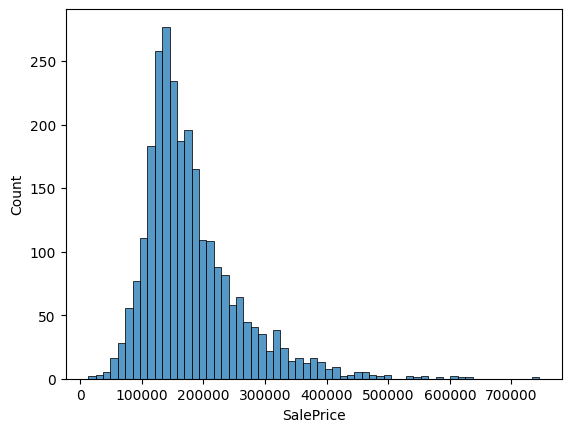

In [ ]:
sns.histplot(df_copy['SalePrice'])

### SalePrice Distribution
SalePrice shows a right skew, meaning most homes sold at lower prices with a long tail of high-value sales.

In [ ]:
#creating variable filter to create histograms of numeric columns
numeric_cols = df_copy.select_dtypes(include='number').columns.tolist()

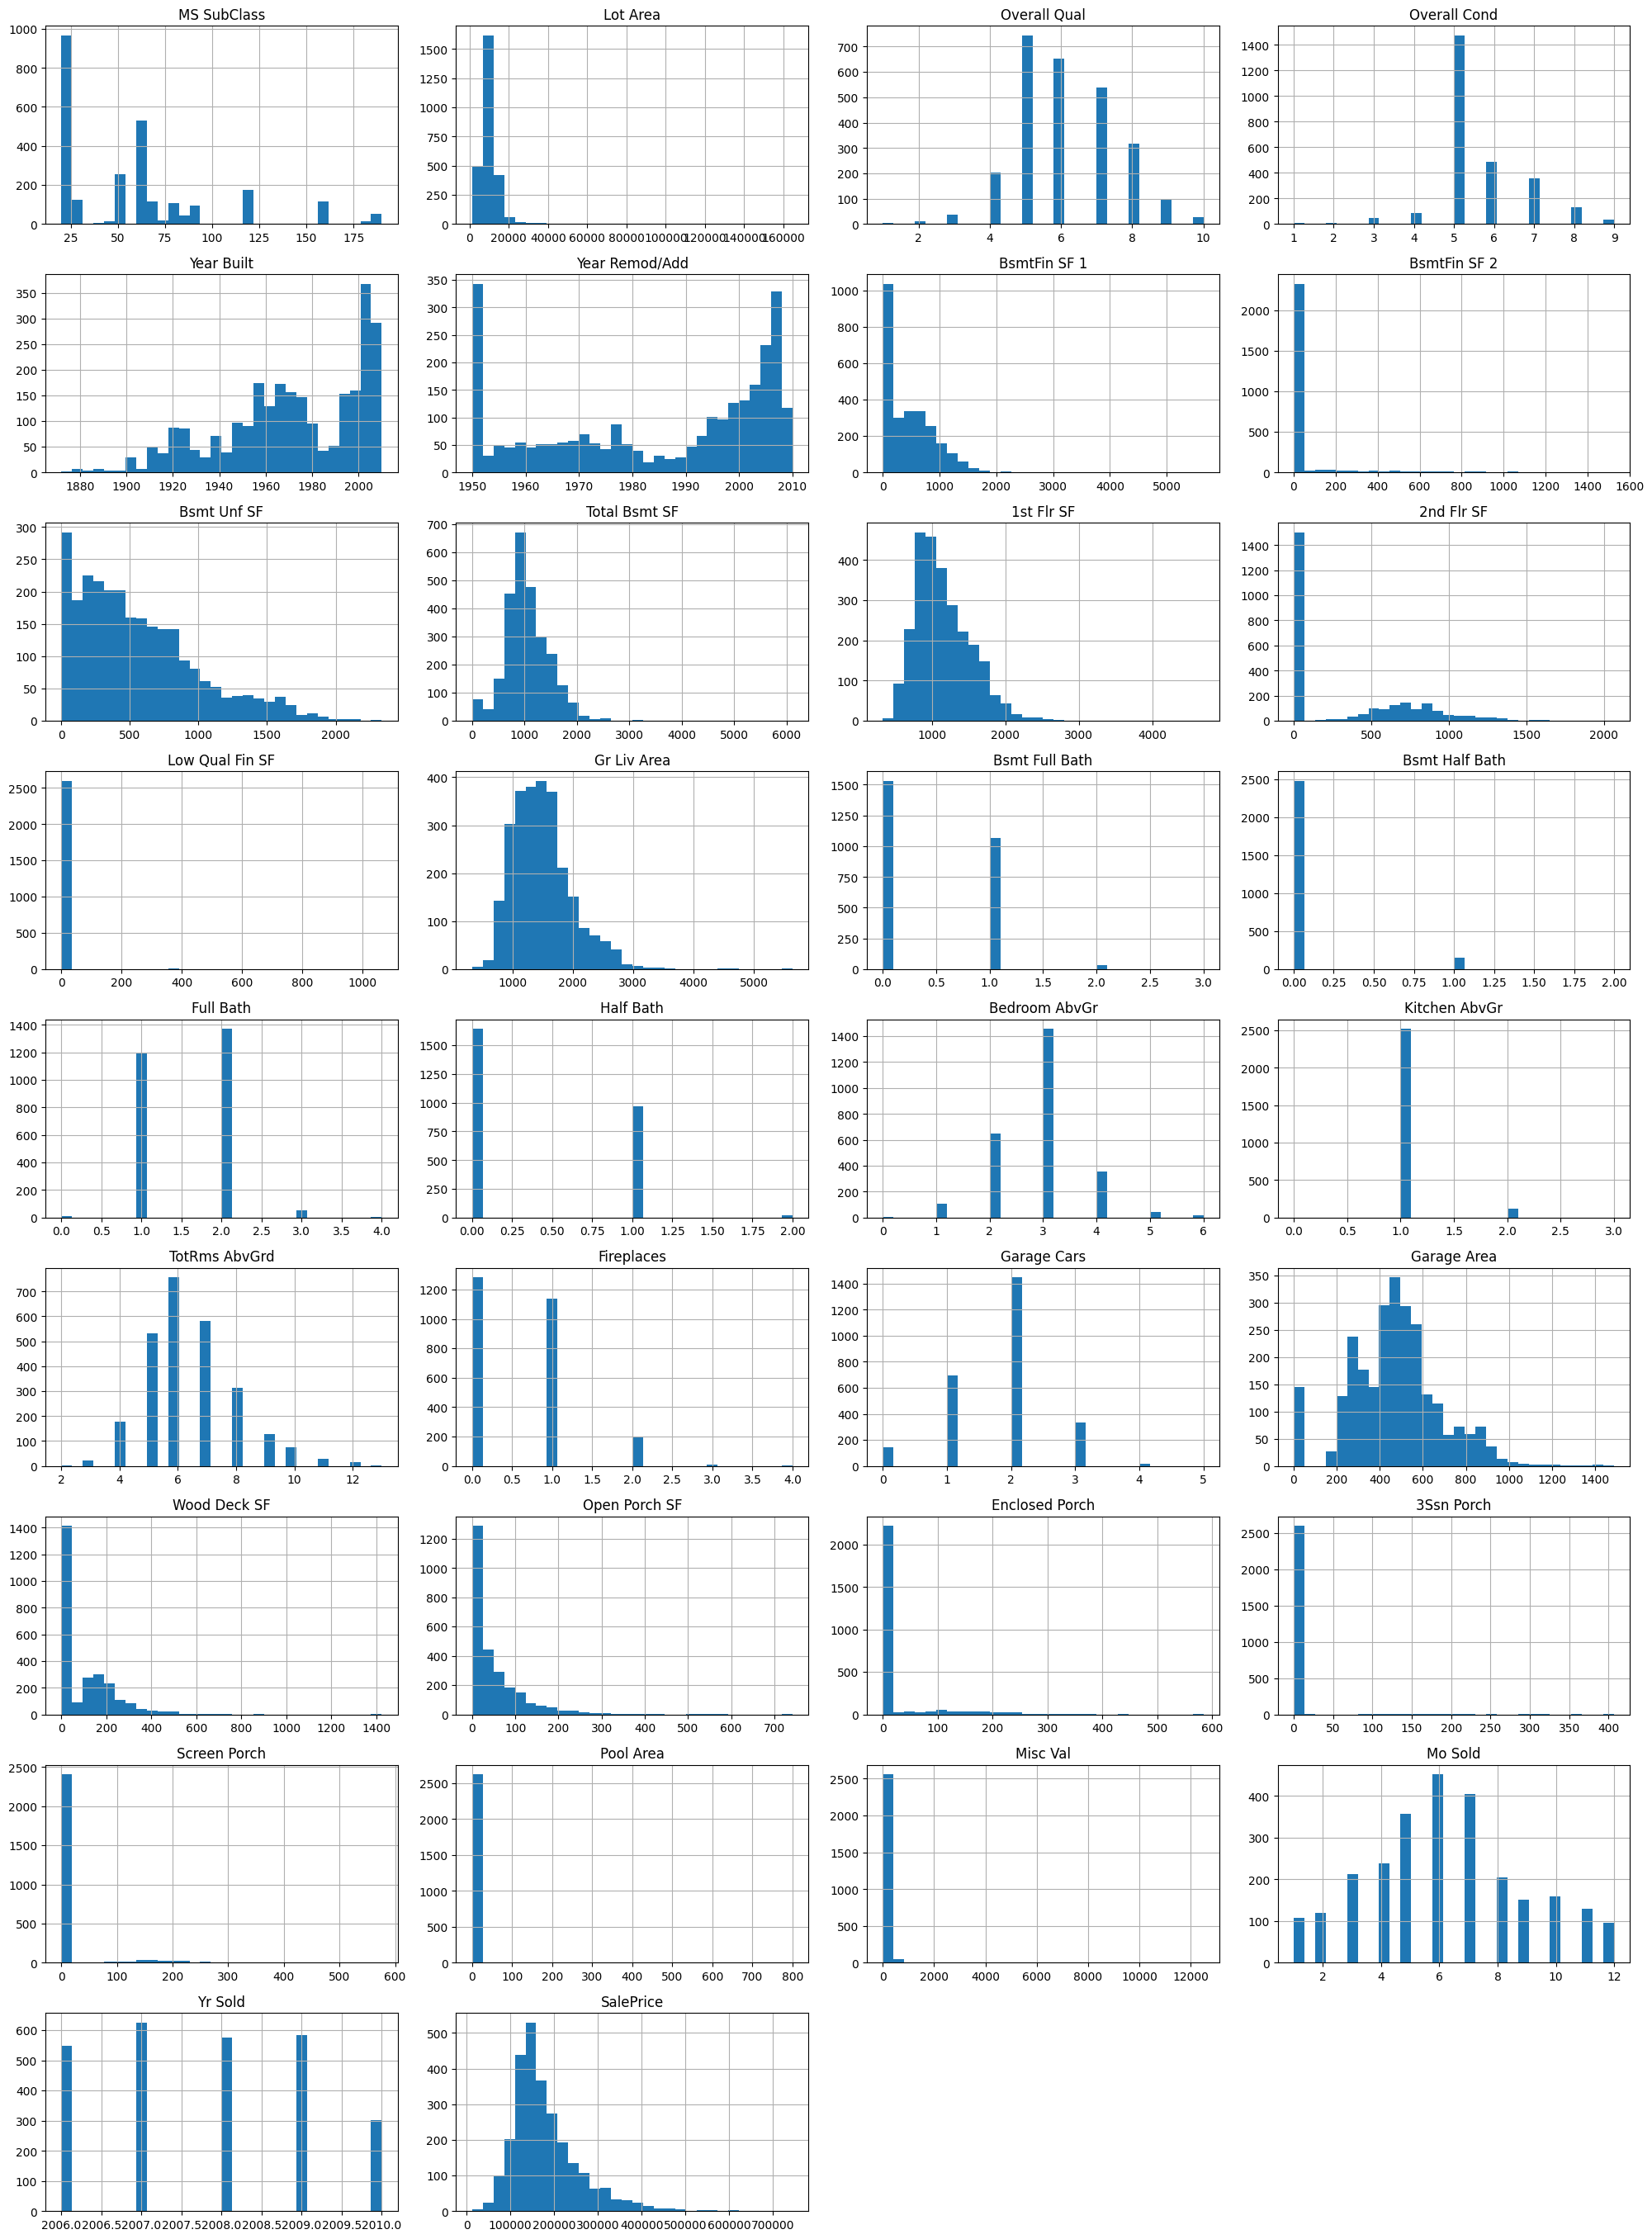

In [ ]:
df_copy[numeric_cols].hist(bins=30, figsize=(20, 30), layout=(10, 4))
pyplot.tight_layout()
pyplot.show()

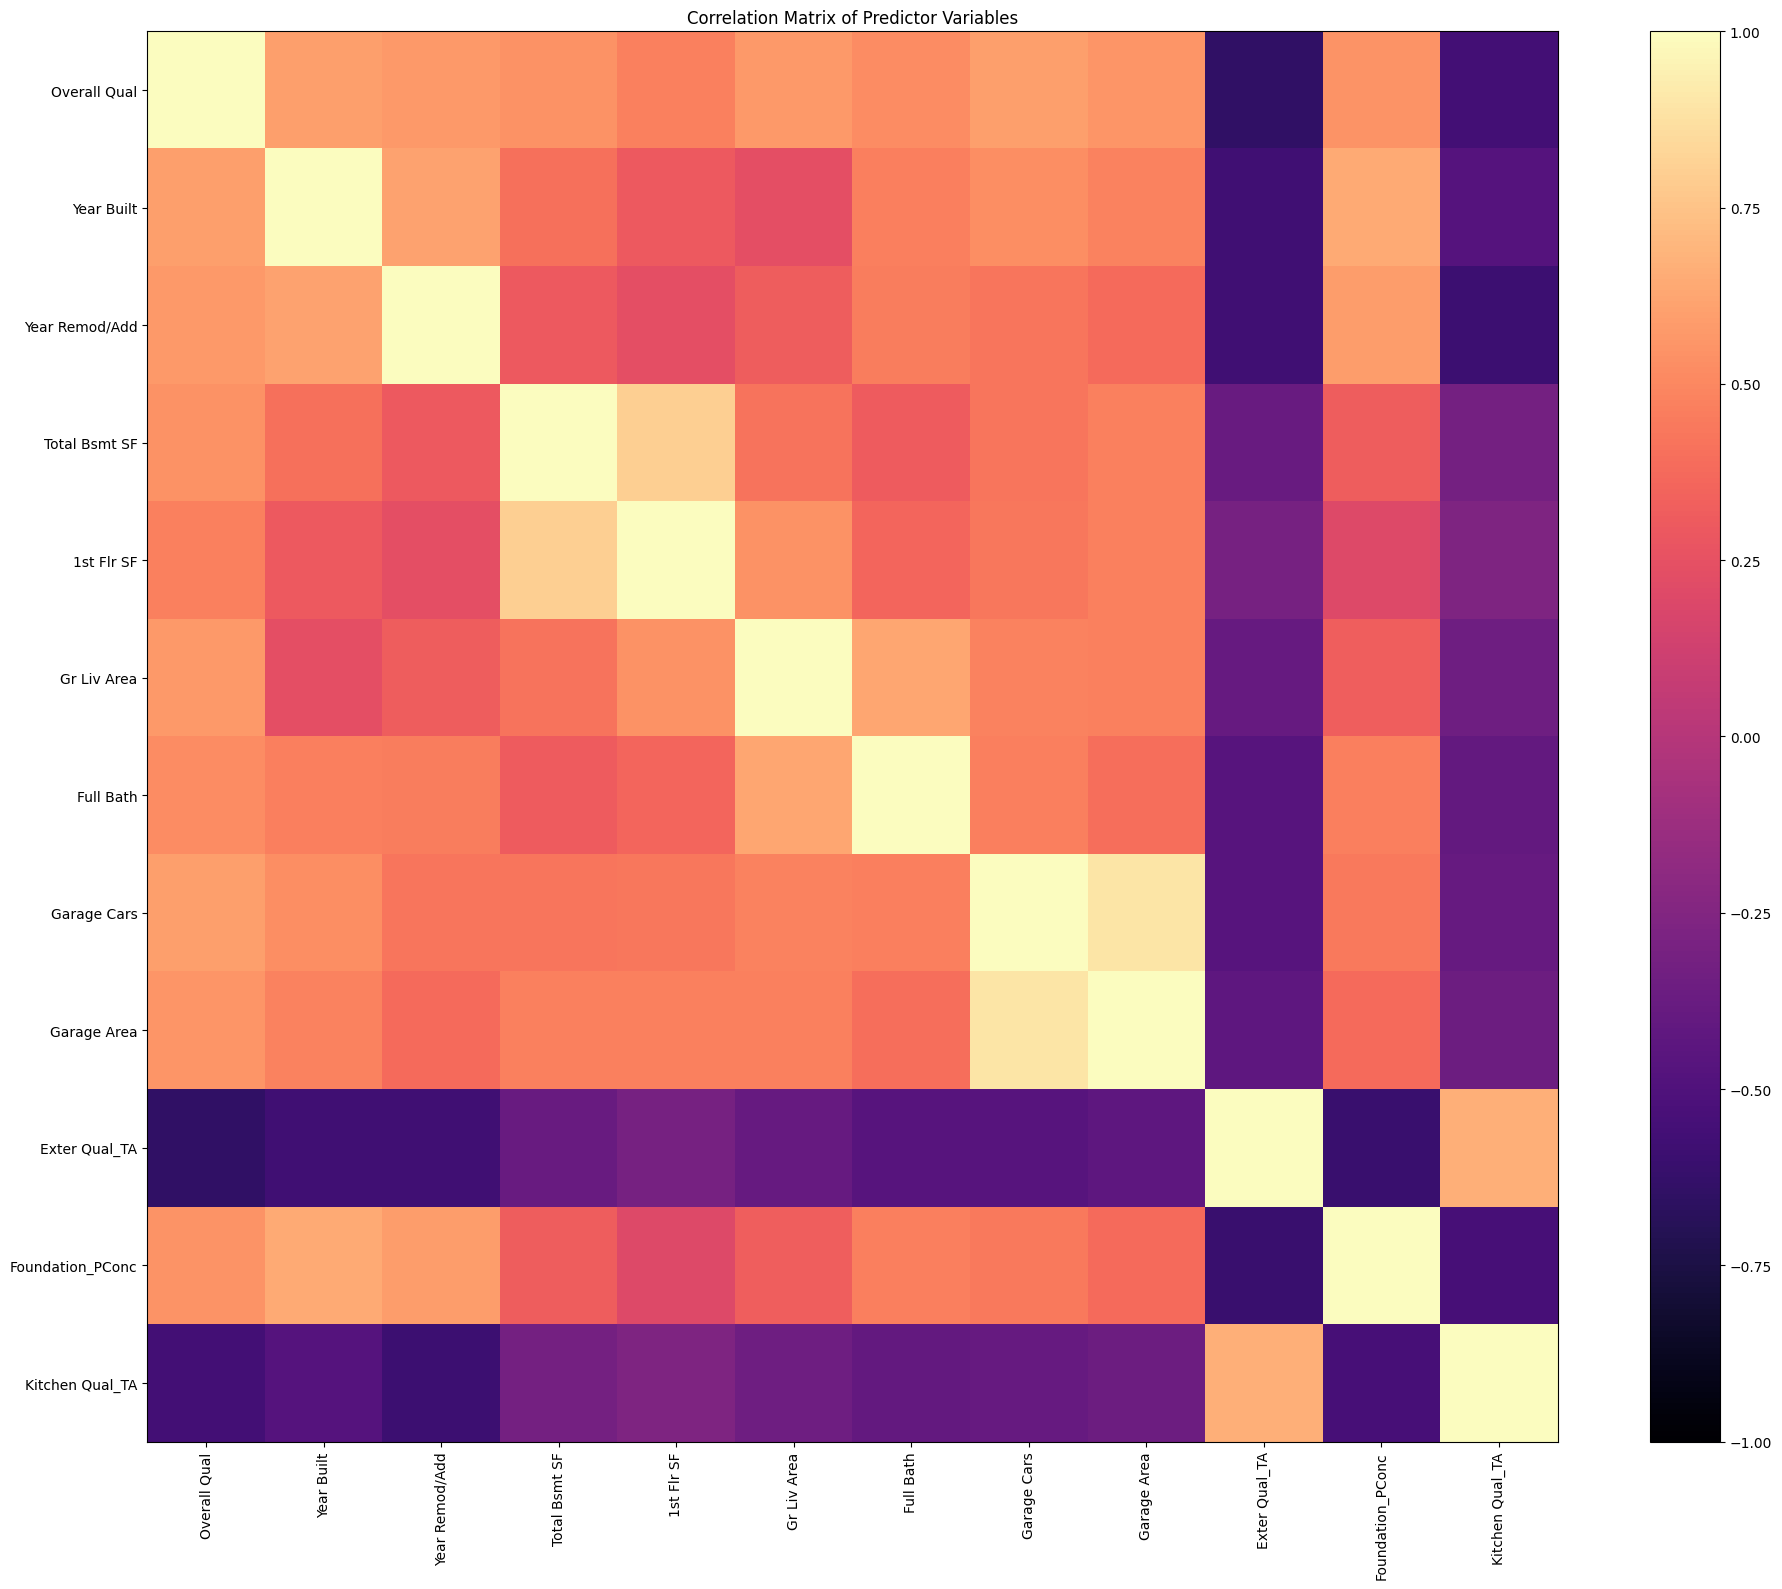

In [ ]:
corr_with_target = df_copy.corr()['SalePrice'].abs()
high_corr_cols = corr_with_target[corr_with_target > 0.5].index.tolist()
high_corr_cols.remove('SalePrice')

corr_matrix = df_copy[high_corr_cols].corr()

pyplot.figure(figsize=(20, 16))
pyplot.imshow(corr_matrix, vmin=-1, vmax=1,cmap='magma')
pyplot.colorbar()
pyplot.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
pyplot.yticks(range(len(corr_matrix)), corr_matrix.columns)
pyplot.title('Correlation Matrix of Predictor Variables')
pyplot.tight_layout()
pyplot.show()

With our features identified from EDA, we now prepare the data for modeling. Features with a correlation coefficient above 0.5 with SalePrice were selected, resulting in 12 features. These features are scaled using `StandardScaler` to normalize the range before applying regularized regression. The data is then split 80/20 into training and testing sets.

## Data Processing

In [ ]:
X = df_copy[high_corr_cols].copy()
y = df_copy['SalePrice'].copy()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Modeling

### Lasso Regularization

In [ ]:
def rmspe(y_true, y_pred):
  ''' Given actual values and predicted values, calculate the root mean squared percentage error'''
  return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

n = 100
results_lasso = np.zeros(n)

for i in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

    model = Lasso(alpha=10000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    results_lasso[i] = rmspe(y_test, y_pred)

print(f"Mean RMSPE: {results_lasso.mean():.4f}")
print(f"Std Dev: {results_lasso.std():.4f}")

y_pred_lasso = y_pred
coef_lasso = model.coef_

Mean RMSPE: 0.2248
Std Dev: 0.0293


Lasso Regularization produces the following results:

- Mean RMSPE: 22.48%
- STD Dev: .0293

### Ridge Regularization

In [ ]:
n = 100
results_ridge = np.zeros(n)

for i in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

    model = Ridge(alpha=.01)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    results_ridge[i] = rmspe(y_test, y_pred)

print(f"Mean RMSPE: {results_ridge.mean():.4f}")
print(f"Std Dev: {results_ridge.std():.4f}")

y_pred_ridge = y_pred
coef_ridge = model.coef_

Mean RMSPE: 0.2178
Std Dev: 0.0307


Ridge Regularization produces the following results:

- Mean RMSPE: 21.78%
- Std Dev: .0307

## Visualization

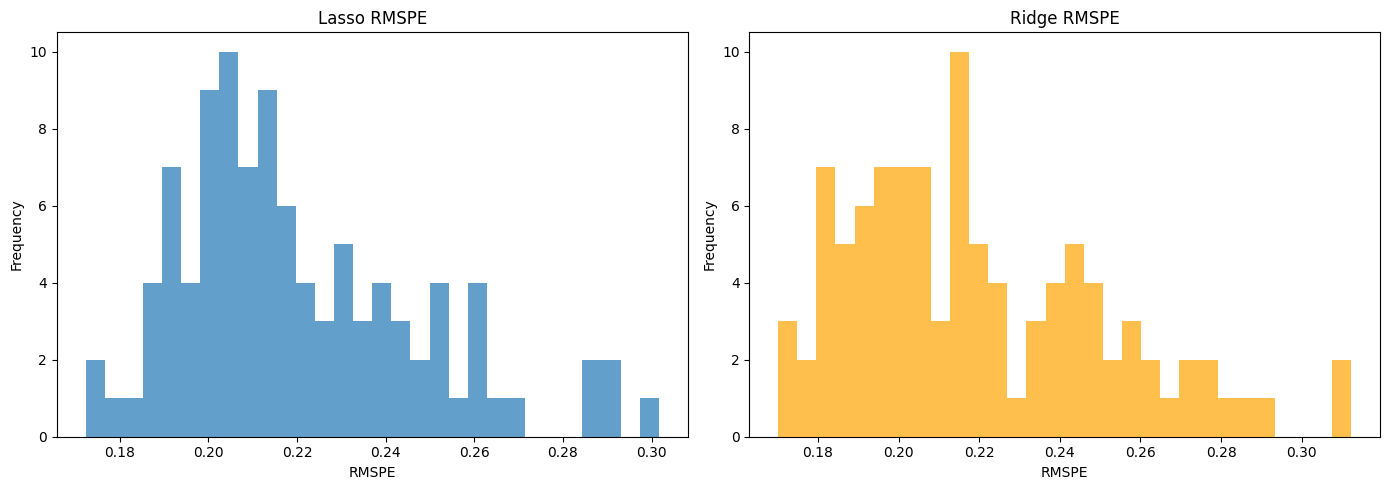

In [ ]:
# RMSPE Histograms

fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))
axes[0].hist(results_lasso, bins=30, alpha=0.7, label='Lasso')
axes[1].hist(results_ridge, bins=30, alpha=0.7, label='Ridge', color='orange')

for ax, title in zip(axes, ['Lasso RMSPE', 'Ridge RMSPE']):
    ax.set_title(title)
    ax.set_xlabel('RMSPE')
    ax.set_ylabel('Frequency')

pyplot.tight_layout()
pyplot.show()


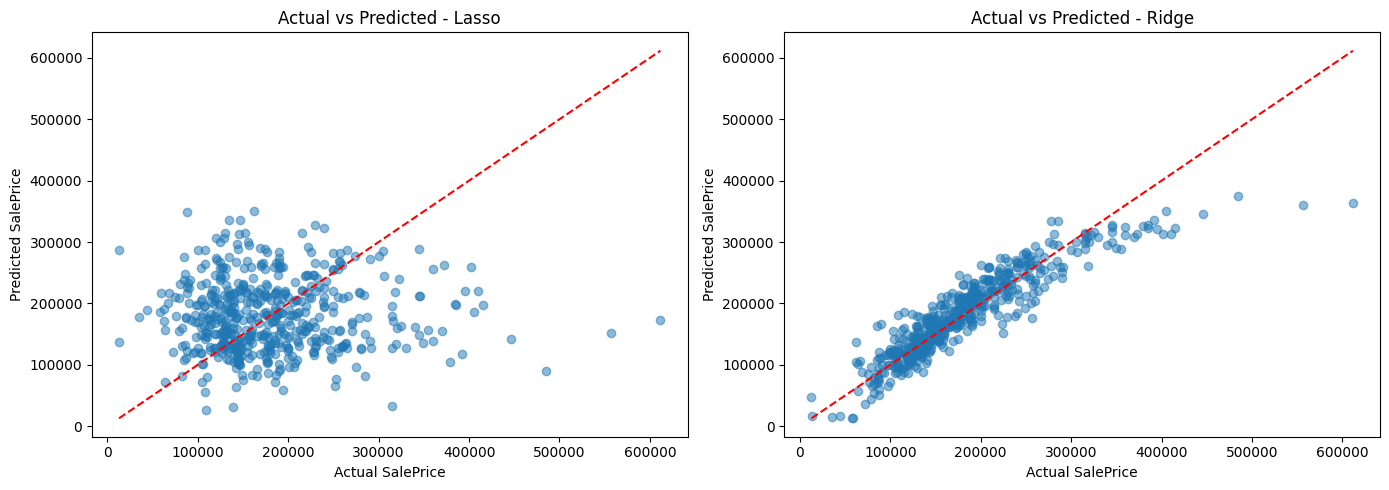

In [ ]:
# Actual vs Predicted
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

for ax, y_p, title in zip(axes, [y_pred_lasso, y_pred_ridge], ['Lasso', 'Ridge']):
    ax.scatter(y_test, y_p, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Actual SalePrice')
    ax.set_ylabel('Predicted SalePrice')
    ax.set_title(f'Actual vs Predicted - {title}')

pyplot.tight_layout()
pyplot.show()

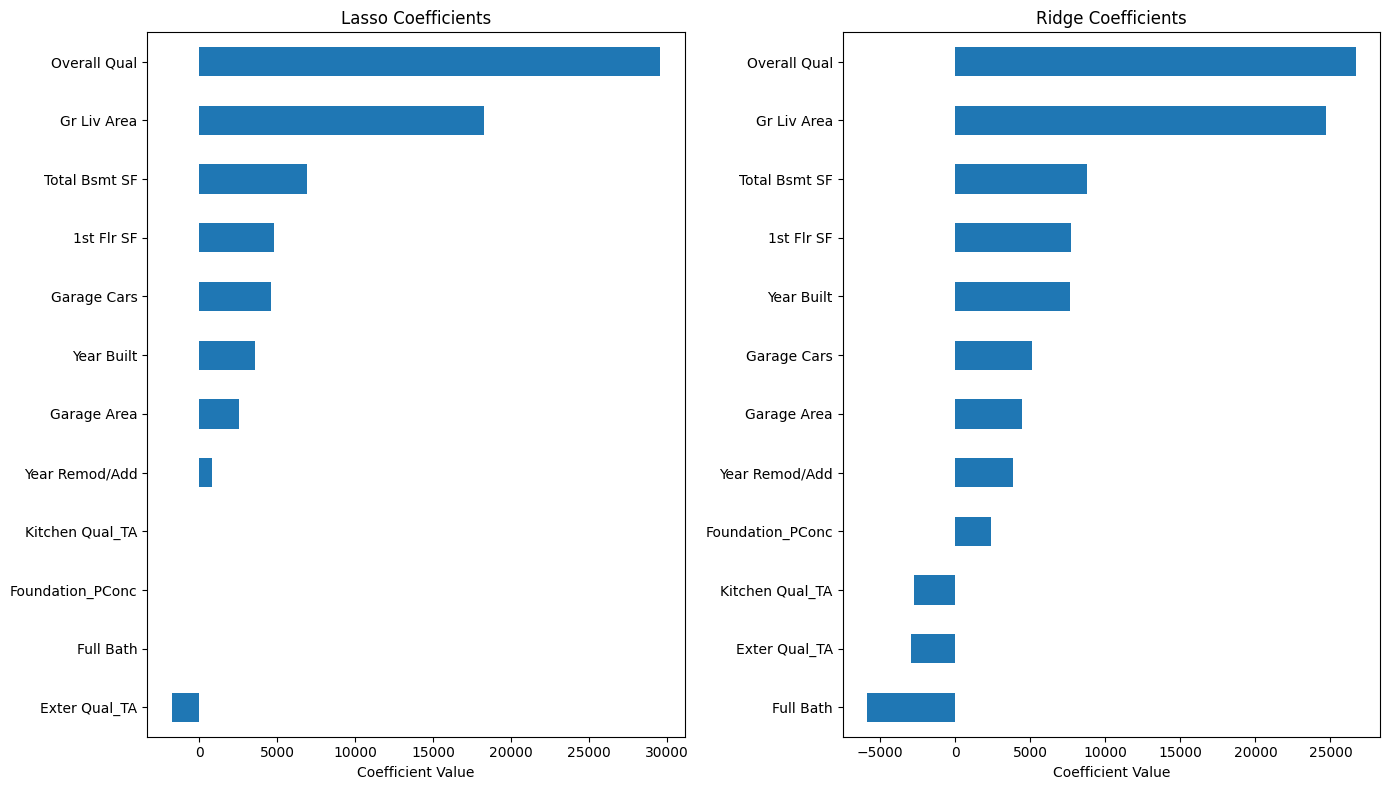

In [ ]:
# Coefficients
fig, axes = pyplot.subplots(1, 2, figsize=(14, 8))

for ax, coef, title in zip(axes, [coef_lasso, coef_ridge], ['Lasso', 'Ridge']):
    pd.Series(coef, index=high_corr_cols).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'{title} Coefficients')
    ax.set_xlabel('Coefficient Value')

pyplot.tight_layout()
pyplot.show()

## Communication of Results

- Our goal was to create a linear regression model using RMSPE as our metric to predict home sales price with a minimal and effective feature set.
  - This was achieved by reducing the number of features from 80 to 12.
  - Our best RMSPE considering Ridge regularization was 21.78%. While this isn't the most optimal value for our metric, it serves as a minimum viable product.
  - Our model has a higher error rate when predicting sales price of homes that are sold at higher than $300,000 , likely due to there being less samples of higher sales price homes

- Closing thoughts:
  - Next time, I would explore doing a logarithmic transformation on our target, Sales Price, because there was a right skew to the values in this sample. I would assume that this would improve the performance of the model.
  - Some features included in the final model may hurt performance and further time could be provided to feature selection in order to improve performance